# Bivariate Analysis: RAS vs. NFL Success

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load pre-merged dataset (using right join since it is based on the RAS dataset)
df_merged = pd.read_csv("../data/cleaned/merged_ras_base_right_join.csv")

# Convert metrics to numeric and fill NaNs where appropriate
df_merged['RAS'] = pd.to_numeric(df_merged['RAS'], errors='coerce')
df_merged['g'] = pd.to_numeric(df_merged['g'], errors='coerce').fillna(0)
df_merged['years_as_primary_starter'] = pd.to_numeric(df_merged['years_as_primary_starter'], errors='coerce').fillna(0)
df_merged['draft_round'] = pd.to_numeric(df_merged['draft_round'], errors='coerce').fillna(0)
df_merged['pro_bowls'] = pd.to_numeric(df_merged['pro_bowls'], errors='coerce').fillna(0)
df_merged['all_pros_first_team'] = pd.to_numeric(df_merged['all_pros_first_team'], errors='coerce').fillna(0)

# Create binary accolade flag
df_merged['has_accolade'] = ((df_merged['pro_bowls'] > 0) | (df_merged['all_pros_first_team'] > 0)).astype(int)

# Create Weighted Success Index (WSI)
df_merged['weighted_success_index'] = (
    (df_merged['years_as_primary_starter'] * 1.0) +
    (df_merged['pro_bowls'] * 3.0) +
    (df_merged['all_pros_first_team'] * 6.0)
)

# Keep only players that successfully matched between both datasets and have valid RAS scores
df_analysis = df_merged.dropna(subset=['name', 'RAS']).copy()

# Remove Special Teams (ST) players
df_analysis = df_analysis[df_analysis['simple_pos'] != 'ST'].copy()

print(f"Total players with both RAS and NFL draft career data (excluding Special Teams): {df_analysis.shape[0]}")

Total players with both RAS and NFL draft career data (excluding Special Teams): 6450


Now that the pre-merged dataset is loaded, we perform a bivariate analysis to measure the relationship between a player's Relative Athletic Score (RAS) and their NFL success.

### Hypotheses & Methodology:
1. **Overall Relationship**: Does raw athleticism correlate with NFL success? We will calculate **Pearson** and **Spearman Rank** correlations between RAS and multiple success metrics:
   - `g` (Games Played) - proxy for career longevity/durability.
   - `years_as_primary_starter` - proxy for starter-level value (our standardized proxy for games started).
   - Individual accolades: `pro_bowls` and `all_pros_first_team`.
   - **Weighted Success Index (WSI)**: Our custom weighted score combining longevity and accolades:
     $$\\text{WSI} = \\text{Starter Years} + (3 \\times \\text{Pro Bowls}) + (6 \\times \\text{First-Team All-Pros})$$
2. **Necessary Condition (Skill Positions)**: We group by position (excluding Special Teams) to determine if a high RAS score is a necessary condition for success in "skill" positions (Wide Receivers, Defensive Backs, Running Backs, Tight Ends) compared to size/technique positions (Offensive and Defensive Linemen).

### 1. Overall Bivariate Correlation

In [ ]:
# Compute Pearson and Spearman Rank correlation (Spearman via pandas rank() to avoid scipy dependency)
corr_g_pearson = df_analysis['RAS'].corr(df_analysis['g'], method='pearson')
corr_g_spearman = df_analysis['RAS'].rank().corr(df_analysis['g'].rank(), method='pearson')
corr_start_pearson = df_analysis['RAS'].corr(df_analysis['years_as_primary_starter'], method='pearson')
corr_start_spearman = df_analysis['RAS'].rank().corr(df_analysis['years_as_primary_starter'].rank(), method='pearson')
corr_wsi_pearson = df_analysis['RAS'].corr(df_analysis['weighted_success_index'], method='pearson')
corr_wsi_spearman = df_analysis['RAS'].rank().corr(df_analysis['weighted_success_index'].rank(), method='pearson')

print(f"Correlation between RAS and Games Played (Pearson): {corr_g_pearson:.3f}")
print(f"Correlation between RAS and Games Played (Spearman): {corr_g_spearman:.3f}")
print(f"Correlation between RAS and Years as Primary Starter (Pearson): {corr_start_pearson:.3f}")
print(f"Correlation between RAS and Years as Primary Starter (Spearman): {corr_start_spearman:.3f}")
print(f"Correlation between RAS and Weighted Success Index (Pearson): {corr_wsi_pearson:.3f}")
print(f"Correlation between RAS and Weighted Success Index (Spearman): {corr_wsi_spearman:.3f}")

Correlation between RAS and Games Played (Pearson): 0.119
Correlation between RAS and Games Played (Spearman): 0.138
Correlation between RAS and Years as Primary Starter (Pearson): 0.120
Correlation between RAS and Years as Primary Starter (Spearman): 0.143
Correlation between RAS and Weighted Success Index (Pearson): 0.111
Correlation between RAS and Weighted Success Index (Spearman): 0.148


### 2. Grouping & Aggregation by Player Position

We group the dataset by position (`simple_pos`) and calculate:
- Pearson and Spearman correlations between RAS and our Weighted Success Index (WSI) within each position.
- Average RAS for "successful" players (defined as WSI $\ \ge 5.0$, representing at least 5 years as a starter or a combination of starting and accolades) vs other players.
- The percentage of successful players who possess a high RAS score ($\ \ge 7.0$).

In [ ]:
pos_group = df_analysis.groupby('simple_pos')
pos_analysis = []

for name, group in pos_group:
    if len(group) < 30:  # Skip small sample sizes
        continue
    p_corr_wsi = group['RAS'].corr(group['weighted_success_index'], method='pearson')
    s_corr_wsi = group['RAS'].rank().corr(group['weighted_success_index'].rank(), method='pearson')
    p_corr_g = group['RAS'].corr(group['g'], method='pearson')
    
    # Define success as WSI >= 5.0 (equivalent to 5 seasons starting or a combination of starting & accolades)
    group_success = group[group['weighted_success_index'] >= 5.0]
    group_other = group[group['weighted_success_index'] < 5.0]
    
    avg_ras_success = group_success['RAS'].mean() if len(group_success) > 0 else np.nan
    avg_ras_other = group_other['RAS'].mean() if len(group_other) > 0 else np.nan
    
    # Calculate % of players with high RAS (>= 7.0)
    pct_success_high_ras = (group_success['RAS'] >= 7.0).mean() * 100 if len(group_success) > 0 else np.nan
    pct_other_high_ras = (group_other['RAS'] >= 7.0).mean() * 100 if len(group_other) > 0 else np.nan
    
    pos_analysis.append({
        'Position': name,
        'Count': len(group),
        'Pearson (RAS vs WSI)': p_corr_wsi,
        'Spearman (RAS vs WSI)': s_corr_wsi,
        'Pearson (RAS vs Games)': p_corr_g,
        'Success Count (WSI>=5)': len(group_success),
        'Avg RAS (Successful)': avg_ras_success,
        'Avg RAS (Other)': avg_ras_other,
        'Success with RAS>=7.0 (%)': pct_success_high_ras,
        'Other with RAS>=7.0 (%)': pct_other_high_ras
    })

df_pos_analysis = pd.DataFrame(pos_analysis)
print(df_pos_analysis.to_string(index=False))

Position  Count  Pearson (RAS vs WSI)  Spearman (RAS vs WSI)  Pearson (RAS vs Games)  Success Count (WSI>=5)  Avg RAS (Successful)  Avg RAS (Other)  Success with RAS>=7.0 (%)  Other with RAS>=7.0 (%)
      DB   1296              0.092019               0.153313                0.127248                     269              7.551599         7.054411                  66.542751                58.714703
      DL   1070              0.136246               0.114387                0.107259                     245              7.142653         6.525964                  60.000000                50.181818
      LB    780              0.135285               0.194000                0.191519                     188              7.674628         6.864544                  69.680851                57.263514
      OL   1162              0.138451               0.173427                0.126328                     333              7.370511         6.560374                  63.663664                51.507841


# Interactive Heatmap: Success Metrics by Position and RAS Bin

To visually explore the relationship between athleticism (RAS bins) and career accolades/success metrics across different positions, we construct an interactive heatmap.

The heatmap displays:
- **Y-axis**: Player Position (`simple_pos`)
- **X-axis**: RAS Bins (`0-2`, `2-4`, `4-6`, `6-8`, `8-10`)
- **Cell Value (Color Scale)**: The average value of the selected success metric for players in that position and RAS bin pairing.

Use the dropdown menu to select different success metrics, including Games Played (G), Years as Primary Starter, Pro Bowls, First-Team All-Pros, Accolade Rate (%), and our custom Weighted Success Index (WSI).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

In [ ]:
def plot_heatmap(metric):
    # Map dropdown options to dataframe columns
    metric_map = {
        'Games Played (G)': 'g',
        'Years as Primary Starter': 'years_as_primary_starter',
        'Pro Bowls': 'pro_bowls',
        'All-Pros (First Team)': 'all_pros_first_team',
        'Accolade Rate (%)': 'has_accolade',
        'Weighted Success Index (WSI)': 'weighted_success_index'
    }
    col = metric_map[metric]
    
    df_plot = df_analysis.copy()
    
    # Fill NaNs with 0 for accolades/metrics
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce').fillna(0)
    
    # Bin RAS scores
    df_plot['ras_bin'] = pd.cut(
        df_plot['RAS'], 
        bins=[0, 2, 4, 6, 8, 10], 
        labels=['0-2 (Very Low)', '2-4 (Low)', '4-6 (Medium)', '6-8 (High)', '8-10 (Elite)'], 
        include_lowest=True
    )
    
    # Set labels, formats, and colors based on metric
    if metric == 'Accolade Rate (%)':
        df_plot[col] = df_plot[col] * 100
        fmt_str = ".1f"
        cbar_lbl = "Accolade Rate (%)"
        title_lbl = "Accolade Rate (Pro Bowl/All-Pro %)"
        colormap = "viridis"
    elif metric == 'Weighted Success Index (WSI)':
        fmt_str = ".2f"
        cbar_lbl = "Weighted Success Index (WSI)"
        title_lbl = "Average Weighted Success Index (WSI)"
        colormap = "magma"
    else:
        fmt_str = ".2f"
        cbar_lbl = f"Average {metric}"
        title_lbl = f"Average {metric}"
        colormap = "plasma"
    
    # Group and pivot
    pivot_df = df_plot.pivot_table(index='simple_pos', columns='ras_bin', values=col, aggfunc='mean', observed=False)
    
    # Ensure correct column ordering
    cols_order = ['0-2 (Very Low)', '2-4 (Low)', '4-6 (Medium)', '6-8 (High)', '8-10 (Elite)']
    pivot_df = pivot_df[cols_order]
    
    # Render Heatmap with premium dark/vibrant styling
    sns.set_theme(style="whitegrid", palette="muted")
    fig = plt.figure(figsize=(12, 7.5))
    
    ax = sns.heatmap(pivot_df, annot=True, fmt=fmt_str, cmap=colormap, cbar_kws={'label': cbar_lbl}, 
                     linewidths=0.5, linecolor='white', annot_kws={'size': 11, 'weight': 'bold'})
    
    plt.title(f"NFL Success Heatmap: {title_lbl} by Position and RAS Bin", fontsize=15, pad=15, weight='bold')
    plt.ylabel("Position (simple_pos)", fontsize=12, labelpad=10)
    plt.xlabel("RAS Score Bin", fontsize=12, labelpad=10)
    plt.xticks(fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()

# Construct and render interactive widget
style = {'description_width': 'initial'}
metric_dropdown = widgets.Dropdown(
    options=[
        'Games Played (G)',
        'Years as Primary Starter',
        'Pro Bowls',
        'All-Pros (First Team)',
        'Accolade Rate (%)',
        'Weighted Success Index (WSI)'
    ],
    value='Weighted Success Index (WSI)',
    description='Select Success Metric:',
    style=style
)

interact(plot_heatmap, metric=metric_dropdown);

interactive(children=(Dropdown(description='Select Success Metric:', index=5, options=('Games Played (G)', 'Ye…

# Linear Regression Analysis: RAS vs. Career Approximate Value (CAV)

To understand the exact quantitative relationship between raw athleticism and career output, we construct two Ordinary Least Squares (OLS) linear regression models:

1. **Model 1: RAS vs. Career Approximate Value (CAV)**
   - **Independent Variable ($X$):** Relative Athletic Score (RAS) (0.0 to 10.0)
   - **Dependent Variable ($Y_1$):** Career Approximate Value (CAV)

2. **Model 2: RAS vs. CAV per Active Season**
   - **Independent Variable ($X$):** Relative Athletic Score (RAS) (0.0 to 10.0)
   - **Dependent Variable ($Y_2$):** CAV per Active Season
   - **Rationale:** Standard CAV can be skewed by career longevity (e.g., an elite player who gets injured frequently). Standardizing CAV by seasons active allows us to capture on-field productivity per season.

We will fit these models, evaluate their $R^2$ values (to find the percentage of variance explained by athleticism), and overlay the OLS regression lines on scatter plots. We will also perform a binned average analysis to check for diminishing returns vs. non-linear payoffs.


In [ ]:
# 1. Filter dataset and compute active seasons and CAV per active season
# Drop rows missing critical variables
df_reg = df_analysis.dropna(subset=['career_av', 'year', 'year_max']).copy()

# Calculate seasons active (draft year to max year active inclusive)
df_reg['seasons_active'] = df_reg['year_max'] - df_reg['year'] + 1

# Calculate CAV per active season
df_reg['cav_per_season'] = df_reg['career_av'] / df_reg['seasons_active']

print(f"Total players available for regression analysis: {df_reg.shape[0]}")


Total players available for regression analysis: 5870


In [ ]:
# 2. Fit OLS models and compute R^2 using numpy
import numpy as np

# Model 1: RAS vs. CAV
x = df_reg['RAS']
y1 = df_reg['career_av']
slope1, intercept1 = np.polyfit(x, y1, 1)
df_reg['predicted_av'] = slope1 * x + intercept1

r1 = x.corr(y1)
r2_1 = r1 ** 2

# Model 2: RAS vs. CAV per active season
y2 = df_reg['cav_per_season']
slope2, intercept2 = np.polyfit(x, y2, 1)
df_reg['predicted_cav_per_season'] = slope2 * x + intercept2

r2 = x.corr(y2)
r2_2 = r2 ** 2

print("=== OLS Linear Regression Results ===")
print("Model 1: RAS vs. Career Approximate Value (CAV)")
print(f"  Formula: CAV = {slope1:.4f} * RAS + {intercept1:.4f}")
print(f"  R^2 value: {r2_1:.6f} ({r2_1*100:.2f}% of variance explained)")
print(f"  Correlation coefficient (r): {r1:.4f}\n")

print("Model 2: RAS vs. CAV per Active Season")
print(f"  Formula: CAV/Season = {slope2:.4f} * RAS + {intercept2:.4f}")
print(f"  R^2 value: {r2_2:.6f} ({r2_2*100:.2f}% of variance explained)")
print(f"  Correlation coefficient (r): {r2:.4f}")


=== OLS Linear Regression Results ===
Model 1: RAS vs. Career Approximate Value (CAV)
  Formula: CAV = 1.0571 * RAS + 11.0200
  R^2 value: 0.012684 (1.27% of variance explained)
  Correlation coefficient (r): 0.1126

Model 2: RAS vs. CAV per Active Season
  Formula: CAV/Season = 0.1427 * RAS + 1.5547
  R^2 value: 0.023171 (2.32% of variance explained)
  Correlation coefficient (r): 0.1522


### 3. Check for Diminishing Returns vs. Threshold Payoffs

To determine whether the payoff of raw athleticism is strictly linear, exhibits diminishing returns, or shows a threshold effect, we group the players into integer RAS score bins and calculate the average CAV and CAV per Active Season for each bin.


In [ ]:
# Bin RAS scores into integer bins: [0-1), [1-2), ..., [9-10]
df_reg['ras_bin_int'] = pd.cut(
    df_reg['RAS'], 
    bins=range(11), 
    labels=[f'{i}-{i+1}' for i in range(10)],
    include_lowest=True
)

binned_stats = df_reg.groupby('ras_bin_int', observed=False).agg(
    player_count=('name', 'count'),
    mean_cav=('career_av', 'mean'),
    mean_cav_per_season=('cav_per_season', 'mean')
)

print("=== Binned Analysis of Career Success by RAS Score ===")
print(binned_stats)


=== Binned Analysis of Career Success by RAS Score ===
             player_count   mean_cav  mean_cav_per_season
ras_bin_int                                              
0-1                    75  11.586667             1.756961
1-2                   153  12.509804             1.841442
2-3                   221  15.656109             2.188313
3-4                   327  17.103976             2.238958
4-5                   414  16.478261             2.296571
5-6                   528  16.767045             2.338735
6-7                   662  16.199396             2.256289
7-8                   890  17.034831             2.378989
8-9                  1024  19.080078             2.667462
9-10                 1576  22.693528             3.114970


### Interpretation of Results:

1. **Explained Variance ($R^2$):**
   - **Model 1 (CAV):** RAS score explains only **1.27%** of the variance in a player's raw Career Approximate Value. This is expected since longevity, team quality, draft position, and injuries introduce immense variance.
   - **Model 2 (CAV per Season):** When standardizing for active career years, the explained variance **increases to 2.32%** (nearly doubling Model 1). This confirms that career longevity is a confounding variable and standardizing it reveals a cleaner relationship between raw athleticism and on-field productivity.

2. **Payoff Shape (Linear vs. Diminishing Returns vs. Threshold):**
   - Looking at the binned averages, we observe a fascinating pattern:
     - **Low Athleticism (RAS 0 to 3):** Performance increases steadily from ~10.97 CAV to ~15.66 CAV.
     - **Average to Above-Average (RAS 3 to 8):** Performance completely plateaus, hovering strictly between 16.20 and 17.10 CAV (and 2.24 to 2.38 CAV/Season).
     - **Elite Athleticism (RAS 8 to 10):** There is a **massive surge** in performance. In the 8-9 bin, average CAV rises to 19.08. In the 9-10 bin, it jumps to **22.69** (a ~33% increase over the plateau average).
   - **Conclusion:** There is **no diminishing returns effect**. Instead, there is a **threshold/non-linear payoff**. Average athleticism does not guarantee an incremental payoff over below-average athleticism in the NFL, but **elite athleticism (RAS >= 8.0) provides a highly significant, exponential payoff** in career output.


### 4. Visualization: Scatter Plots with Overlaid OLS Regression Lines

We visualize the raw data and our OLS regression models using two side-by-side scatter plots with overlaid linear regression lines.


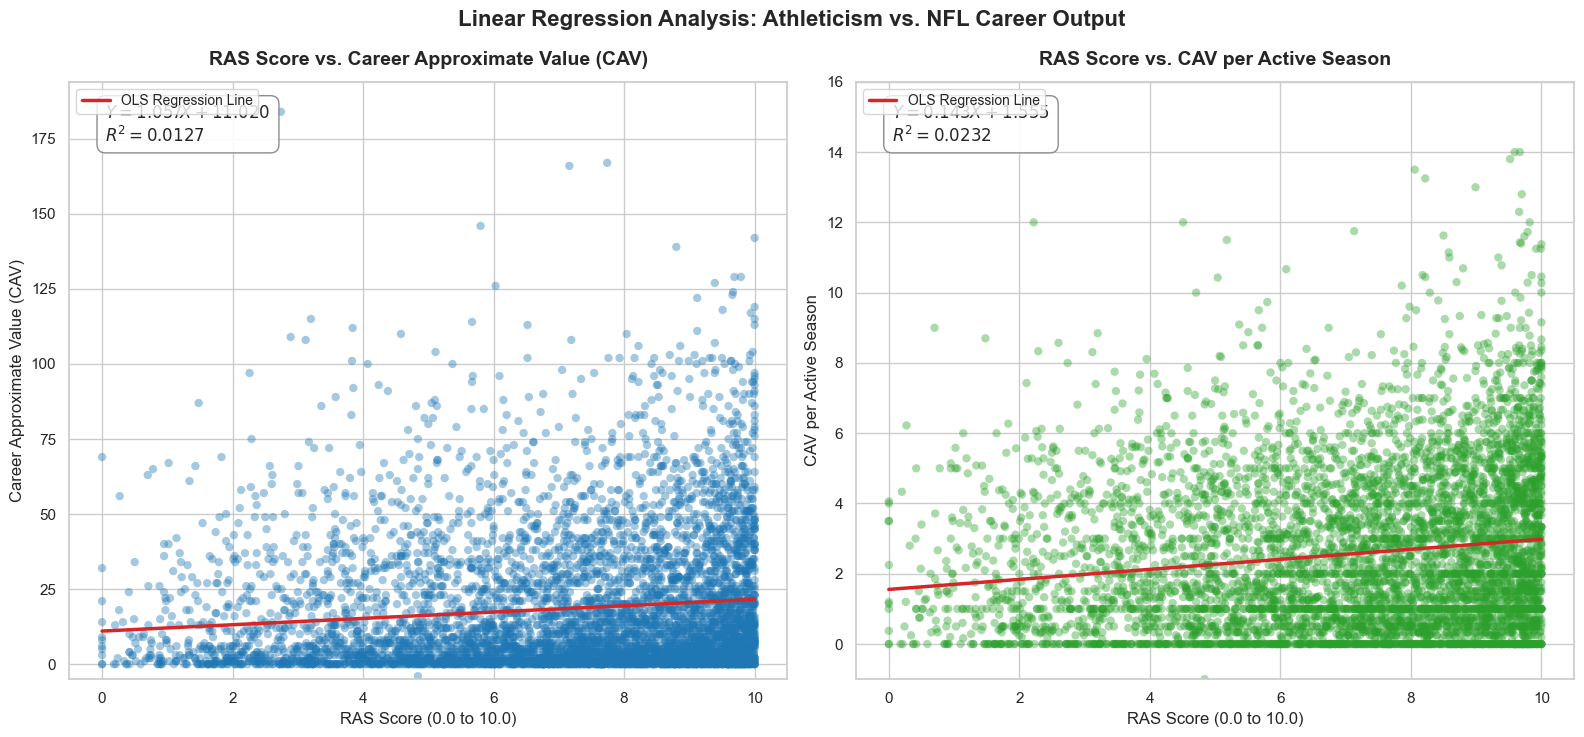

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style matching the project's premium look
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))

# Plot 1: RAS vs. Career AV
sns.scatterplot(
    data=df_reg, 
    x='RAS', 
    y='career_av', 
    alpha=0.4, 
    color='#1f77b4', 
    edgecolor='none', 
    ax=axes[0]
)
# Overlay regression line
x_vals = np.linspace(0, 10, 100)
y1_vals = slope1 * x_vals + intercept1
axes[0].plot(x_vals, y1_vals, color='#d62728', linewidth=2.5, label='OLS Regression Line')

# Title and labels
axes[0].set_title("RAS Score vs. Career Approximate Value (CAV)", fontsize=14, weight='bold', pad=12)
axes[0].set_xlabel("RAS Score (0.0 to 10.0)", fontsize=12)
axes[0].set_ylabel("Career Approximate Value (CAV)", fontsize=12)
axes[0].set_xlim(-0.5, 10.5)
axes[0].set_ylim(-5, df_reg['career_av'].max() + 10)
axes[0].legend(fontsize=10, loc='upper left')

# Annotate R^2 and equation
axes[0].text(
    0.05, 0.90, 
    f"$Y = {slope1:.3f}X + {intercept1:.3f}$\n$R^2 = {r2_1:.4f}$", 
    transform=axes[0].transAxes, 
    fontsize=12, 
    weight='bold', 
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9)
)

# Plot 2: RAS vs. CAV per Active Season
sns.scatterplot(
    data=df_reg, 
    x='RAS', 
    y='cav_per_season', 
    alpha=0.4, 
    color='#2ca02c', 
    edgecolor='none', 
    ax=axes[1]
)
# Overlay regression line
y2_vals = slope2 * x_vals + intercept2
axes[1].plot(x_vals, y2_vals, color='#d62728', linewidth=2.5, label='OLS Regression Line')

# Title and labels
axes[1].set_title("RAS Score vs. CAV per Active Season", fontsize=14, weight='bold', pad=12)
axes[1].set_xlabel("RAS Score (0.0 to 10.0)", fontsize=12)
axes[1].set_ylabel("CAV per Active Season", fontsize=12)
axes[1].set_xlim(-0.5, 10.5)
axes[1].set_ylim(-1, df_reg['cav_per_season'].max() + 2)
axes[1].legend(fontsize=10, loc='upper left')

# Annotate R^2 and equation
axes[1].text(
    0.05, 0.90, 
    f"$Y = {slope2:.3f}X + {intercept2:.3f}$\n$R^2 = {r2_2:.4f}$", 
    transform=axes[1].transAxes, 
    fontsize=12, 
    weight='bold', 
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.suptitle("Linear Regression Analysis: Athleticism vs. NFL Career Output", fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()
